In [1]:
%load_ext autoreload
%autoreload 2

In [3]:
import numpy as np
import matplotlib.pyplot as plt

import sys
sys.path.append("../src")


from geodesiq import *

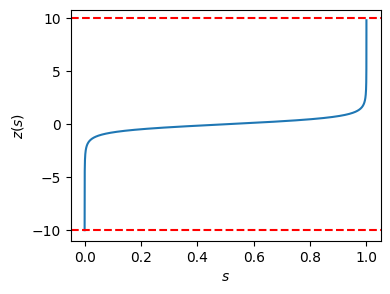

In [18]:
# ----- Define Hamiltonian and its gradient -----
def H_fun(x, z):
    return np.array([[z, x],
                     [x, -z]])

def H_partial(x, z):
    return np.array([[1, 0],
                     [0, -1]])

hamiltonian = Hamiltonian(H_fun, H_partial)

# ----- Set system and control parameters -----
alpha = 5
beta = 5
x = 1
z0 = -10
zf = -z0

hamiltonian.set_parameters(x=x)
hamiltonian.set_control(control_name='z', pulse_initial=z0, pulse_final=zf,
                        initial_state=0, alpha=alpha, beta=beta)

# ----- Solve for optimal pulse -----
hamiltonian.solve_problem(pulse_accuracy=int(1e6))


# ----- Plot the resulting pulse -----
s, pulse = hamiltonian._s, hamiltonian.control_sol

fig, ax = plt.subplots(figsize=(4,3))
ax.plot(s, pulse)

ax.axhline(z0, c='r', ls='--')
ax.axhline(zf, c='r', ls='--')

ax.set_xlabel(r'$s$')
ax.set_ylabel(r'$z(s)$');